# 1. 변수 전처리
: KFGI folder에서 Ridge, PCA, Factor Analysis 3가지 방법을 통해 K-FGI를 추출하여 비교 결과, Ridge 채택

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/1576689814.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/1576689814.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, ax=axes_imp[i], palette='viridis')
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/1576689814.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=impo

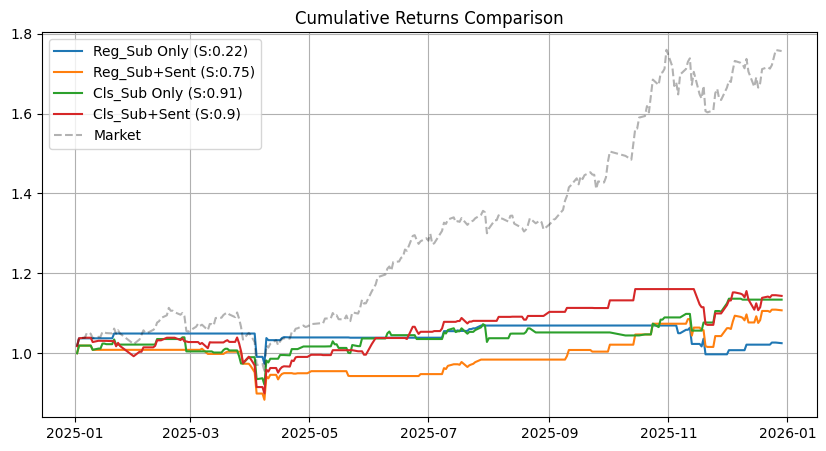

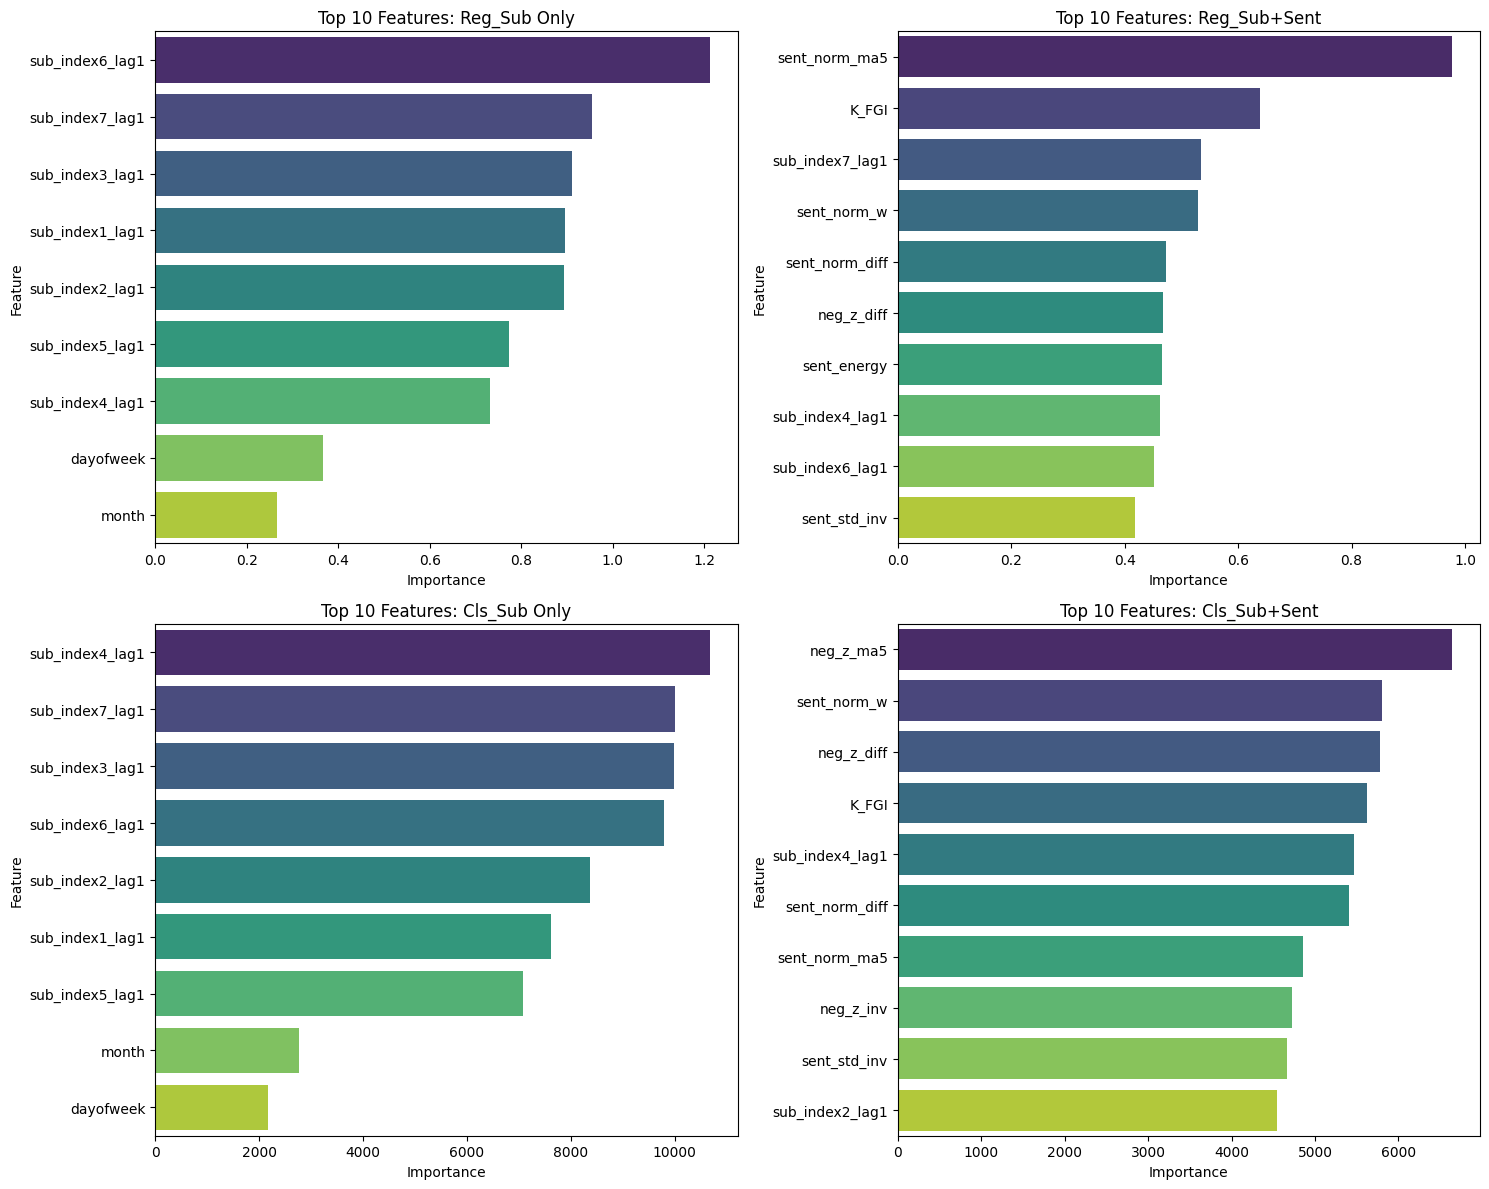


===== 벤치마크 결과 요약 =====
       Model  Sharpe Return
Reg_Sub Only   0.223  2.60%
Reg_Sub+Sent   0.754 10.68%
Cls_Sub Only   0.915 13.17%
Cls_Sub+Sent   0.897 14.03%


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 가이드 기반 피처 엔지니어링 (동일)
input_file = '/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv'
df = pd.read_csv(input_file)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

def build_advanced_features(df):
    df = df.copy()
    '''
    추후 예측에 사용할 변수 미리 생성
    '''
    df['neg_z_inv'] = -df['neg_z']
    df['sent_std_inv'] = -df['sent_std']
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_diff'] = df['sent_norm_w'].diff()
    df['neg_z_diff'] = df['neg_z'].diff()
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

    sub_cols = [f'sub_index{i}' for i in range(1, 8)]
    for col in sub_cols:
        df[f'{col}_lag1'] = df[col].shift(1)

    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['target_reg'] = df['log_return_t+1']
    df['target_cls'] = (df['log_return_t+1'] > 0).astype(int)
    df['sample_weight'] = np.log1p(df['effective_n'])

    return df.dropna().reset_index(drop=True)

# 앞으로 사용하게 될 dataset
df_eng = build_advanced_features(df)

# 2. K-FGI 지수 생성 (Ridge)
def create_kfgi(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + \
                 ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv']
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all_scaled = scaler.transform(df[core_feats])
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train_scaled, df.loc[train_mask, 'target_reg'])
    w = ridge.coef_ / np.sum(np.abs(ridge.coef_))
    raw = X_all_scaled @ w
    p1, p99 = np.percentile(raw[train_mask], [1, 99])
    df['K_FGI'] = 100 * (np.clip(raw, p1, p99) - p1) / (p99 - p1)
    return df, core_feats, w

df_fgi, core_feats, w = create_kfgi(df_eng)


# 3. 통합 비교 실험 및 피처 중요도 분석
'''
Sub_index만 있는 데이터 vs Sub_index + sentiment 데이터 비교 in Regression, Classification
'''

def run_full_analysis(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    test_mask = df['date'] > train_end

    sub_only = [f'sub_index{i}_lag1' for i in range(1, 8)] + ['dayofweek', 'month']
    with_sent = sub_only + ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                            'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

    experiments = [
        ('Reg', 'Sub Only', sub_only),
        ('Reg', 'Sub+Sent', with_sent),
        ('Cls', 'Sub Only', sub_only),
        ('Cls', 'Sub+Sent', with_sent)
    ]

    summary = []
    fig_cum, ax_cum = plt.subplots(figsize=(10, 5))
    fig_imp, axes_imp = plt.subplots(2, 2, figsize=(15, 12))
    axes_imp = axes_imp.flatten()

    for i, (m_type, f_type, f_list) in enumerate(experiments):
        target = 'target_reg' if m_type == 'Reg' else 'target_cls'

        # 모델 학습
        dtrain = lgb.Dataset(df.loc[train_mask, f_list], label=df.loc[train_mask, target],
                             weight=df.loc[train_mask, 'sample_weight'])
        params = {'objective': 'regression' if m_type == 'Reg' else 'binary', 'verbosity': -1, 'learning_rate': 0.02}
        model = lgb.train(params, dtrain, num_boost_round=300)

        # 예측 및 성과
        preds = model.predict(df.loc[test_mask, f_list])
        actual_ret = df.loc[test_mask, 'log_return_t+1']
        signal = (preds > 0) if m_type == 'Reg' else (preds > 0.5)
        strat_ret = signal * actual_ret

        # 지표 산출
        ann_ret = strat_ret.mean() * 252
        ann_vol = (strat_ret.std() * np.sqrt(252)) + 1e-9
        sharpe = ann_ret / ann_vol

        summary.append({'Model': f"{m_type}_{f_type}", 'Sharpe': round(sharpe, 3), 'Return': f"{ann_ret*100:.2f}%"})

        # 수익 곡선 플롯
        ax_cum.plot(df.loc[test_mask, 'date'], np.exp(strat_ret.cumsum()), label=f"{m_type}_{f_type} (S:{round(sharpe,2)})")

        # 피처 중요도 플롯
        importances = pd.DataFrame({'Feature': f_list, 'Importance': model.feature_importance(importance_type='gain')})
        importances = importances.sort_values(by='Importance', ascending=False).head(10)
        sns.barplot(x='Importance', y='Feature', data=importances, ax=axes_imp[i], palette='viridis')
        axes_imp[i].set_title(f"Top 10 Features: {m_type}_{f_type}")

    # 최종 결과 정리
    ax_cum.plot(df.loc[test_mask, 'date'], np.exp(actual_ret.cumsum()), 'k--', label='Market', alpha=0.3)
    ax_cum.set_title("Cumulative Returns Comparison")
    ax_cum.legend(); ax_cum.grid(True)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary)

# 실행 및 결과 출력
results = run_full_analysis(df_fgi)
print("\n===== 벤치마크 결과 요약 =====")
print(results.to_string(index=False))

# 2. 지수 분석

(1) 계수 정렬 및 시각화

In [2]:
print(df_fgi['K_FGI'].corr(df_fgi['sub_index5']))

-0.3692941338639088


In [3]:
df_eng['kospi_close'].corr(df_eng['sub_index5'])

np.float64(-0.44301678709910947)

=== Ridge Coefficients (정렬) ===
neg_z_inv       0.118319
sub_index4      0.103086
sub_index1      0.047311
sent_norm_w     0.033951
sub_index3      0.013787
sub_index2     -0.033519
sub_index6     -0.081448
sent_energy    -0.091719
sub_index7     -0.135242
sent_std_inv   -0.137144
sub_index5     -0.204474
dtype: float64


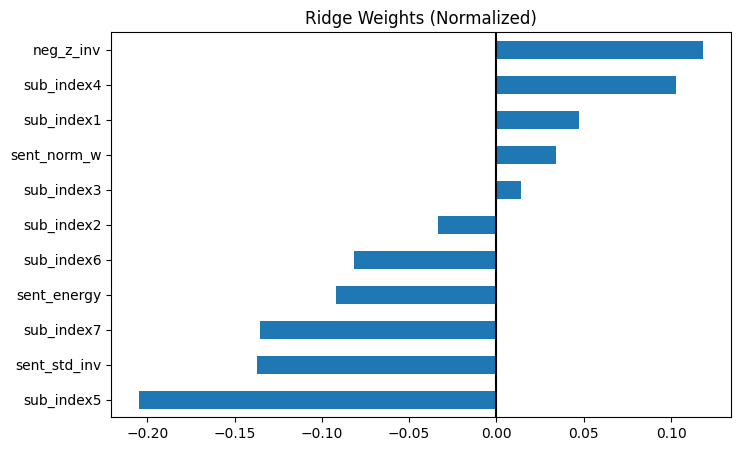

In [4]:
coef_df = pd.Series(w, index=core_feats).sort_values(ascending=False)

print("=== Ridge Coefficients (정렬) ===")
print(coef_df)

plt.figure(figsize=(8,5))
coef_df.sort_values().plot(kind='barh')
plt.title("Ridge Weights (Normalized)")
plt.axvline(0, color='black')
plt.show()

(2) 절대 기여도 확인

In [13]:
importance_ratio = coef_df.abs() / coef_df.abs().sum()

print("=== Absolute Contribution Ratio ===")
print(importance_ratio.sort_values(ascending=False))

=== Absolute Contribution Ratio ===
sub_index5      0.204474
sent_std_inv    0.137144
sub_index7      0.135242
neg_z_inv       0.118319
sub_index4      0.103086
sent_energy     0.091719
sub_index6      0.081448
sub_index1      0.047311
sent_norm_w     0.033951
sub_index2      0.033519
sub_index3      0.013787
dtype: float64


In [36]:
df.columns

Index(['date', 'sub_index1', 'sub_index2', 'sub_index3', 'sub_index4',
       'sub_index5', 'sub_index6', 'sub_index7', 'sent_norm_w',
       'sent_strength_w', 'sent_std', 'neg_z', 'effective_n', 'heat',
       'kospi_close', 'log_return', 'log_return_t+1', 'neg_z_inv',
       'sent_std_inv', 'sent_energy', 'sent_norm_diff', 'neg_z_diff',
       'sent_norm_ma5', 'neg_z_ma5', 'sub_index1_lag1', 'sub_index2_lag1',
       'sub_index3_lag1', 'sub_index4_lag1', 'sub_index5_lag1',
       'sub_index6_lag1', 'sub_index7_lag1', 'dayofweek', 'month',
       'target_reg', 'target_cls', 'sample_weight', 'K_FGI', 'ret_1d',
       'fgi_quantile', 'signal', 'strategy_ret', 'cum_strategy', 'cum_kospi',
       'ret_2d', 'ret_3d', 'K_new'],
      dtype='object')

## 지수 정당성 입증 코드
(A) 극단 구간 평균 분석

In [14]:
fear_zone = df_fgi[df_fgi['K_FGI'] < 20]
greed_zone = df_fgi[df_fgi['K_FGI'] > 80]

print("Fear zone mean next return:", fear_zone['log_return_t+1'].mean())
print("Greed zone mean next return:", greed_zone['log_return_t+1'].mean())

print("Fear zone mean volatility:", fear_zone['neg_z'].mean())
print("Greed zone mean volatility:", greed_zone['neg_z'].mean())

print("Counts:", len(fear_zone), len(greed_zone))

Fear zone mean next return: -0.0012291880398439797
Greed zone mean next return: 0.00440602270900645
Fear zone mean volatility: -0.2960027678249466
Greed zone mean volatility: 0.8601024700046191
Counts: 130 49


In [20]:
print(df_fgi['K_FGI'].corr(df_fgi['kospi_close']))

-0.11712434205660223


(B) 지수와 주요 변수 간 상관관계

In [15]:
check_vars = ['neg_z', 'neg_z_inv', 'sent_norm_w', 'sent_energy']
corr_check = df_fgi[['K_FGI'] + check_vars].corr()

print(corr_check['K_FGI'].sort_values(ascending=False))

K_FGI          1.000000
neg_z          0.284407
sent_norm_w    0.012377
sent_energy   -0.253841
neg_z_inv     -0.284407
Name: K_FGI, dtype: float64


(C) 지수 시계열 + 시장 비교

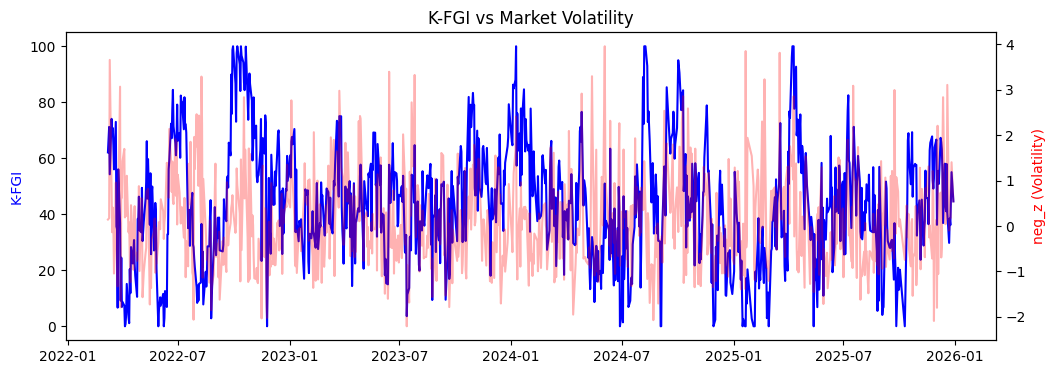

In [16]:
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(df_fgi['date'], df_fgi['K_FGI'], color='blue')
ax1.set_ylabel("K-FGI", color='blue')

ax2 = ax1.twinx()
ax2.plot(df_fgi['date'], df_fgi['neg_z'], color='red', alpha=0.3)
ax2.set_ylabel("neg_z (Volatility)", color='red')

plt.title("K-FGI vs Market Volatility")
plt.show()

(D) 지수 안정성 (Rolling std)

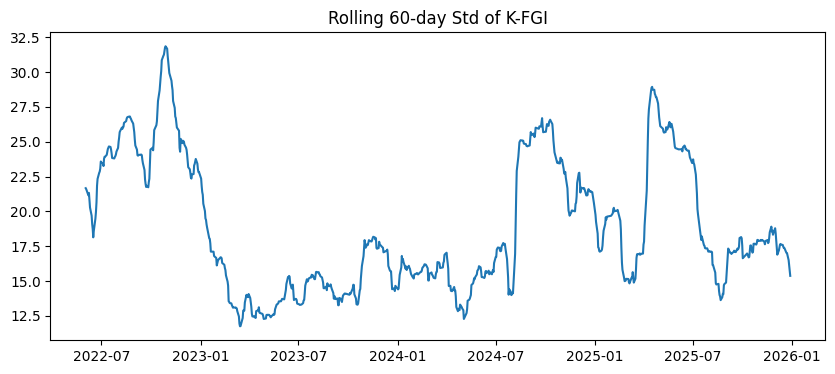

In [17]:
rolling_std = df_fgi['K_FGI'].rolling(60).std()

plt.figure(figsize=(10,4))
plt.plot(df_fgi['date'], rolling_std)
plt.title("Rolling 60-day Std of K-FGI")
plt.show()

(E) 지수 단독 전략 확인 (예측력 참고용)

In [18]:
signal = df_fgi['K_FGI'] > 60
ret = df_fgi['log_return_t+1']

strat_ret = signal * ret

ann_ret = strat_ret.mean() * 252
ann_vol = strat_ret.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol

print("KFGI standalone Sharpe:", sharpe)

KFGI standalone Sharpe: 1.1291054919641497


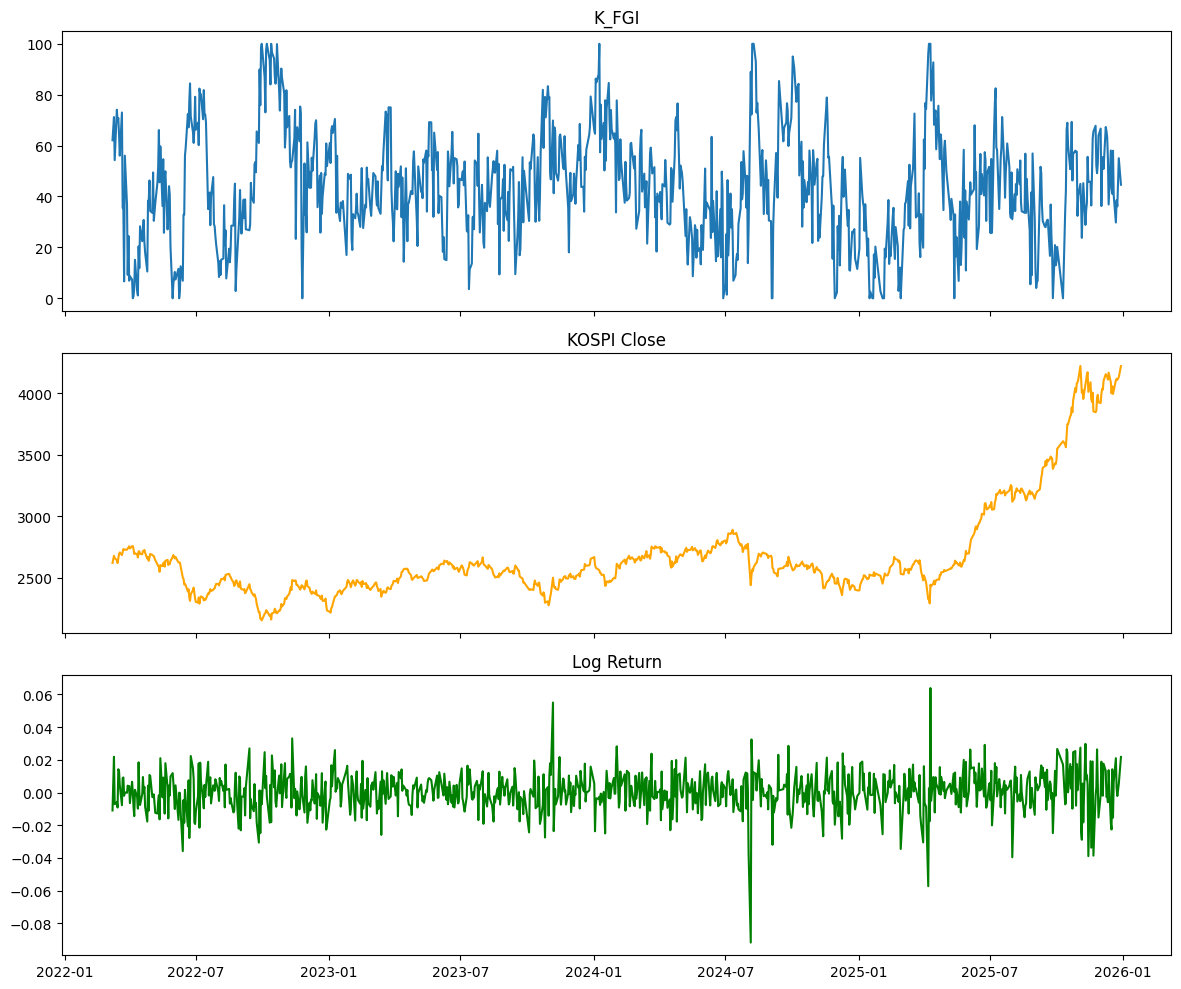

In [43]:
#%%
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_fgi['date'], df_fgi['K_FGI'], label='K_FGI')
axes[0].set_title("K_FGI")

axes[1].plot(df_fgi['date'], df_fgi['kospi_close'], color='orange')
axes[1].set_title("KOSPI Close")

axes[2].plot(df_fgi['date'], df_fgi['log_return'], color='green')
axes[2].set_title("Log Return")

plt.tight_layout()
plt.show()

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/2096420405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['K_FGI_rev'] = 100 - df_test['K_FGI']
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/2096420405.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['K_FGI_scaled'] = df_test['K_FGI_rev']


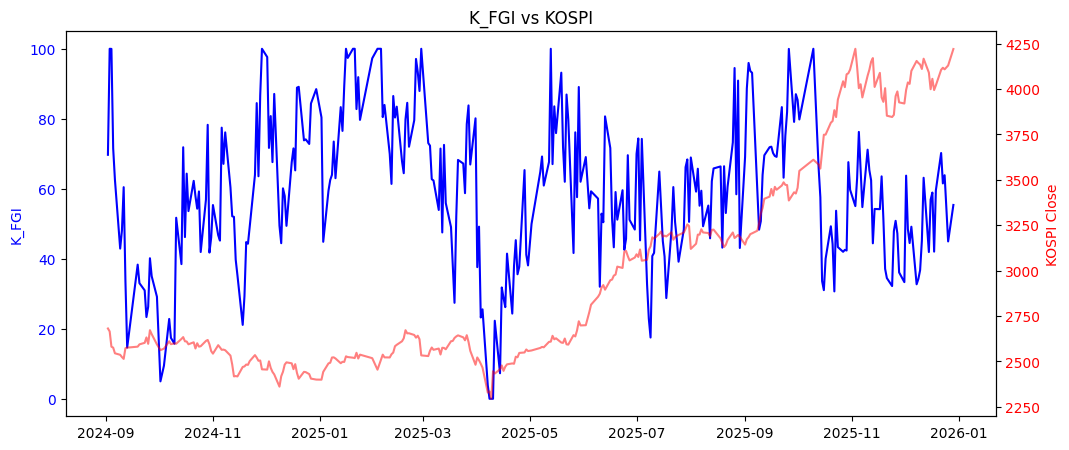

In [25]:
fig, ax1 = plt.subplots(figsize=(12,5))

window = df_fgi['date'] > '2024-09-01'
df_test = df_fgi[window]
df_test['K_FGI_rev'] = 100 - df_test['K_FGI']

# K_FGI
df_test['K_FGI_scaled'] = df_test['K_FGI_rev']
ax1.plot(df_test['date'], df_test['K_FGI_scaled'], color='blue', label='K_FGI')
ax1.set_ylabel('K_FGI', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


# KOSPI (보조축)
ax2 = ax1.twinx()
ax2.plot(df_test['date'], df_test['kospi_close'], color='red', alpha=0.5, label='KOSPI Close')
ax2.set_ylabel('KOSPI Close', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("K_FGI vs KOSPI")
plt.show()

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/2734771578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test[['K_FGI_norm','kospi_norm']] = scaler.fit_transform(
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/2734771578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test[['K_FGI_norm','kospi_norm']] = scaler.fit_transform(


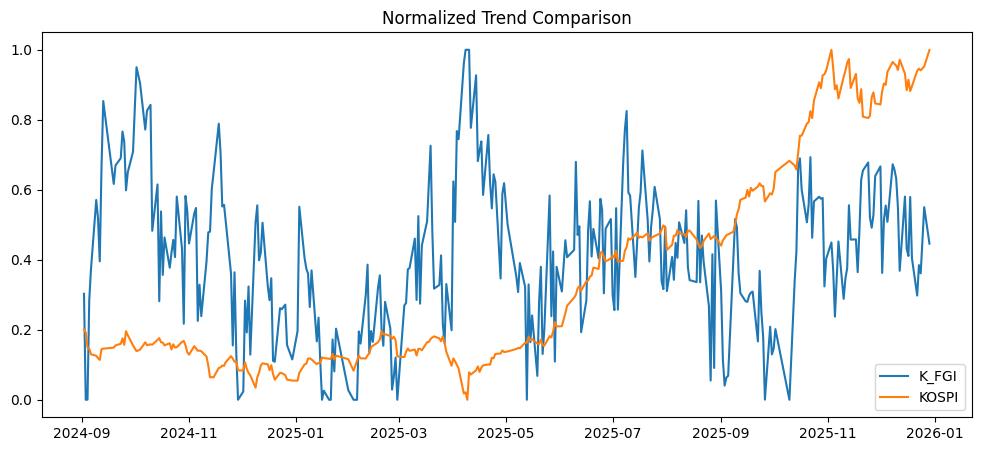

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_test[['K_FGI_norm','kospi_norm']] = scaler.fit_transform(
    df_test[['K_FGI','kospi_close']]
)

plt.figure(figsize=(12,5))
plt.plot(df_test['date'], df_test['K_FGI_norm'], label='K_FGI')
plt.plot(df_test['date'], df_test['kospi_norm'], label='KOSPI')
plt.legend()
plt.title("Normalized Trend Comparison")
plt.show()

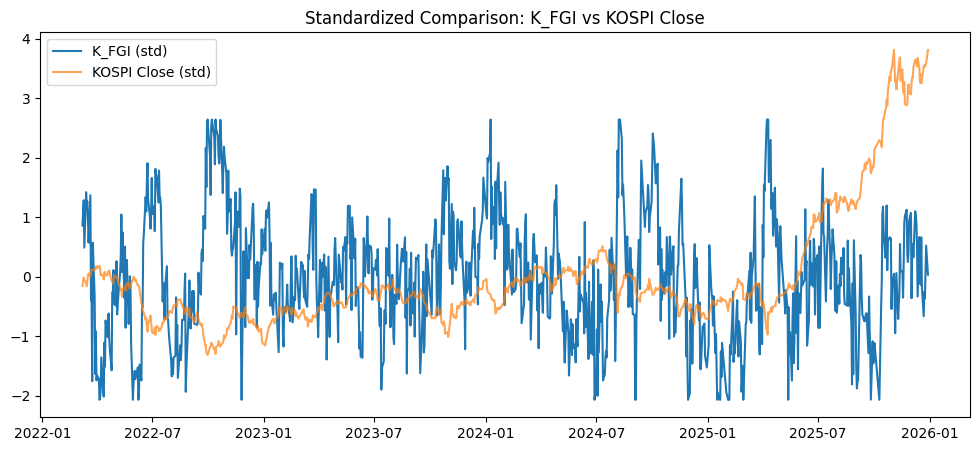

In [51]:
#%%
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

kfg_norm = scaler.fit_transform(df_fgi[['K_FGI']])
kospi_norm = scaler.fit_transform(df_fgi[['kospi_close']])

plt.figure(figsize=(12,5))
plt.plot(df_fgi['date'], kfg_norm, label='K_FGI (std)')
plt.plot(df_fgi['date'], kospi_norm, label='KOSPI Close (std)', alpha=0.7)

plt.title("Standardized Comparison: K_FGI vs KOSPI Close")
plt.legend()
plt.show()

In [61]:
print("Correlation (level):",
      df_fgi['K_FGI'].corr(df_fgi['log_return_t+1']))

Correlation (level): 0.10209966733223409


In [63]:
# 분위수 나누기
df_fgi['quantile'] = pd.qcut(df_fgi['K_FGI'], 5, labels=False)

summary = df_fgi.groupby('quantile').agg({
    'K_FGI':'mean',
    'log_return':'mean',
    'log_return_t+1':'mean'
})

print(summary)

              K_FGI  log_return  log_return_t+1
quantile                                       
0         14.591318   -0.000923       -0.000608
1         32.543671    0.000106       -0.001437
2         43.241232    0.000763        0.001882
3         54.354199    0.001647        0.000427
4         74.521928    0.000898        0.002282


In [64]:
df_fgi['down'] = (df_fgi['log_return'] < 0).astype(int)

down_rate = df_fgi.groupby('quantile')['down'].mean()
print(down_rate)

quantile
0    0.502674
1    0.465241
2    0.446237
3    0.454545
4    0.459893
Name: down, dtype: float64


In [66]:
vkospi = pd.read_csv("/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/sub_index5_7_final.csv")
vkospi['date'] = pd.to_datetime(vkospi['Unnamed: 0'])

df_fgi = df_fgi.merge(vkospi[['date','VKOSPI']], on='date', how='left')

In [ ]:
print(df_fgi.groupby('quantile')['VKOSPI'].mean())  

quantile
0    18.046471
1    19.206150
2    19.376129
3    19.619679
4    22.522567
Name: VKOSPI, dtype: float64


In [71]:
print('kospi와 VKOSPI 상관관계 : ', df_fgi['VKOSPI'].corr(df_fgi['kospi_close']), '\n')
print('log_return와 VKOSPI 상관관계 : ', df_fgi['VKOSPI'].corr(df_fgi['log_return']), '\n')
print('log_return_t+1와 VKOSPI 상관관계 : ', df_fgi['VKOSPI'].corr(df_fgi['log_return_t+1']))

kospi와 VKOSPI 상관관계 :  0.5205187904934901 

log_return와 VKOSPI 상관관계 :  -0.08634634897232228 

log_return_t+1와 VKOSPI 상관관계 :  0.11634966201145718


In [74]:
print(df_fgi['VKOSPI'].corr(df_fgi['log_return']))
print(df_fgi['VKOSPI'].diff().corr(df_fgi['log_return']))
print(df_fgi['VKOSPI'].corr(df_fgi['kospi_close'].pct_change()))
print(df_fgi['VKOSPI'].diff().corr(df_fgi['log_return_t+1']))

-0.08634634897232228
-0.6168082693351811
-0.07898502872397374
0.06468636572079911


In [76]:
print(df_fgi['K_FGI'].corr(df_fgi['log_return_t+1']))
print(df_fgi['K_FGI'].corr(df_fgi['kospi_close']))

0.10209966733223409
-0.11712434205660223


In [12]:
import pandas as pd
import numpy as np

df = df_fgi.copy()
df = df.sort_values("date").reset_index(drop=True)

# 로그수익률
df["ret_1d"] = np.log(df["kospi_close"] / df["kospi_close"].shift(1))

max_lag = 5
corrs = {}

for lag in range(max_lag + 1):
    corrs[lag] = df["K_FGI"].corr(df["ret_1d"].shift(-lag))

corr_table = pd.DataFrame.from_dict(corrs, orient="index", columns=["corr"])
corr_table.index.name = "lag (FGI -> future return)"
print(corr_table)

                                corr
lag (FGI -> future return)          
0                           0.060482
1                           0.102108
2                           0.113380
3                           0.090864
4                           0.068123
5                           0.082581


In [13]:
df = df.dropna().copy()

df["fgi_quantile"] = pd.qcut(df["K_FGI"], 5, labels=False)

quantile_ret = (
    df.groupby("fgi_quantile")["ret_1d"]
      .mean()
      .to_frame("mean_next_day_return")
)

print(quantile_ret)

              mean_next_day_return
fgi_quantile                      
0                        -0.000923
1                         0.000047
2                         0.000818
3                         0.001633
4                         0.000979


In [14]:
df = df.copy()

# 하위 20% / 상위 20%
low_th = df["K_FGI"].quantile(0.2)
high_th = df["K_FGI"].quantile(0.8)

df["signal"] = 0
df.loc[df["K_FGI"] <= low_th, "signal"] = 1      # 공포 → 매수
df.loc[df["K_FGI"] >= high_th, "signal"] = -1    # 탐욕 → 매도

df["strategy_ret"] = df["signal"] * df["ret_1d"]
df["cum_strategy"] = (1 + df["strategy_ret"]).cumprod()
df["cum_kospi"] = (1 + df["ret_1d"]).cumprod()

print("전략 평균수익:", df["strategy_ret"].mean())
print("전략 hit ratio:", (df["strategy_ret"] > 0).mean())

전략 평균수익: -0.00038115025441194276
전략 hit ratio: 0.1907824222936763


In [15]:
df["ret_2d"] = np.log(df["kospi_close"].shift(-2) / df["kospi_close"])
df["ret_3d"] = np.log(df["kospi_close"].shift(-3) / df["kospi_close"])

In [16]:
max_lag = 5
corrs = {}

for lag in range(max_lag + 1):
    corrs[lag] = df["K_FGI"].corr(df["ret_2d"].shift(-lag))

corr_table = pd.DataFrame.from_dict(corrs, orient="index", columns=["corr"])
corr_table.index.name = "lag (FGI -> future return)"
print(corr_table)

                                corr
lag (FGI -> future return)          
0                           0.152365
1                           0.147001
2                           0.114704
3                           0.108222
4                           0.086695
5                           0.067061


In [17]:
max_lag = 5
corrs = {}

for lag in range(max_lag + 1):
    corrs[lag] = df["K_FGI"].corr(df["ret_3d"].shift(-lag))

corr_table = pd.DataFrame.from_dict(corrs, orient="index", columns=["corr"])
corr_table.index.name = "lag (FGI -> future return)"
print(corr_table)

                                corr
lag (FGI -> future return)          
0                           0.179556
1                           0.161850
2                           0.143198
3                           0.112543
4                           0.103145
5                           0.071160


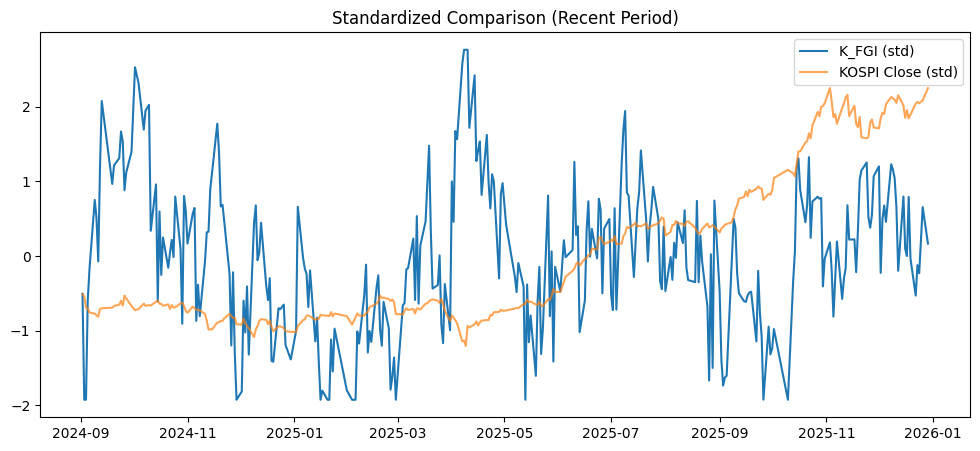

In [20]:
df_plot = df_fgi[df_fgi['date'] >= '2024-09-01'].copy()

scaler = StandardScaler()

kfg_norm = scaler.fit_transform(df_plot[['K_FGI']])
kospi_norm = scaler.fit_transform(df_plot[['kospi_close']])

plt.figure(figsize=(12,5))
plt.plot(df_plot['date'], kfg_norm, label='K_FGI (std)')
plt.plot(df_plot['date'], kospi_norm, label='KOSPI Close (std)', alpha=0.7)
plt.legend()
plt.title("Standardized Comparison (Recent Period)")
plt.show()

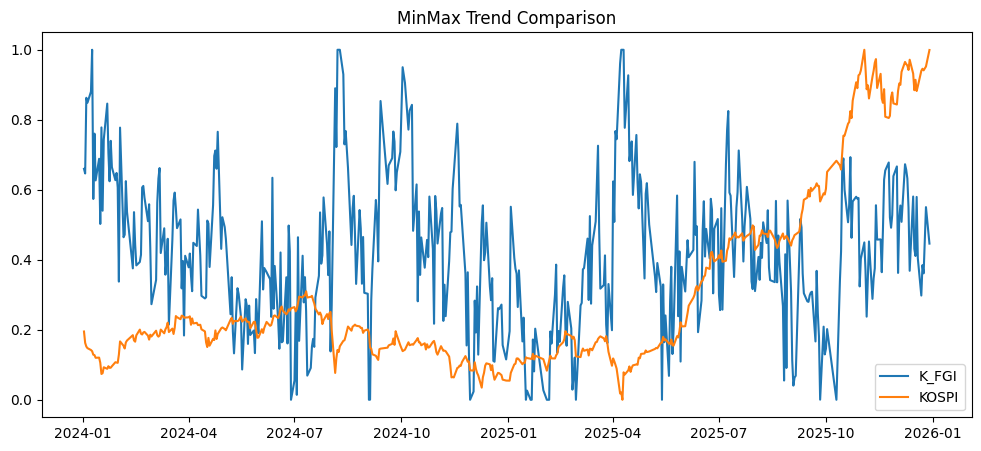

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

norm = scaler.fit_transform(df_plot[['K_FGI','kospi_close']])

plt.figure(figsize=(12,5))
plt.plot(df_plot['date'], norm[:,0], label='K_FGI')
plt.plot(df_plot['date'], norm[:,1], label='KOSPI')
plt.legend()
plt.title("MinMax Trend Comparison")
plt.show()

In [23]:
subset = df[(df['date']>='2022-03-01') & (df['date']<='2023-09-01')]

subset["K_FGI"].corr(subset["kospi_close"])

np.float64(-0.5889111179402197)

In [27]:
df["K_new"] = 100 - df["K_FGI"]

print(df["K_new"].corr(df["kospi_close"]))
print(df['K_FGI'].corr(df['kospi_close']))

0.11703076270975722
-0.11703076270975726


In [28]:
df["K_new"].corr(df["ret_3d"])

np.float64(-0.17955554999286574)

In [29]:
df["K_new"] = 100 - df["K_FGI"]
print("Price corr:", df["K_new"].corr(df["kospi_close"]))

Price corr: 0.11703076270975722


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def validate_sentiment_index(
    df,
    date_col="date",
    price_col="kospi_close",
    idx_col="K_FGI",
    use_inverted=False,          # True면 100-idx로 검증
    crisis_q=0.10,               # “급락일” 정의: 수익률 하위 10%
    calm_q=0.90,                 # “급등일” 정의: 수익률 상위 10%
    ma_window=10,                # 시각화용 스무딩
    vol_proxy_col=None,          # 있으면 (예: 'VKOSPI') 같이 검증
    volume_col=None,             # 있으면 (예: 거래량) 같이 검증
):
    """
    심리지표 검증용 5단계:
    1) 급락일/급등일/평시 구간 분리
    2) 구간별 지수 평균/분포 비교
    3) 급락 이벤트 전후(event study)에서 지수 반응 확인
    4) (옵션) 변동성/거래량 proxy와의 동행성 확인
    5) 핵심 결과표 + 그림 출력
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col).reset_index(drop=True)

    # 로그수익률
    d["ret_1d"] = np.log(d[price_col] / d[price_col].shift(1))

    # 지수 재정의 (원하면 100 - idx)
    if use_inverted:
        d["idx_used"] = 100 - d[idx_col]
        idx_name = f"100 - {idx_col}"
    else:
        d["idx_used"] = d[idx_col]
        idx_name = idx_col

    # 스무딩(보기 좋게)
    d["idx_ma"] = d["idx_used"].rolling(ma_window).mean()
    d["px_ma"] = d[price_col].rolling(ma_window).mean()

    # 급락/급등 임계값
    lo = d["ret_1d"].quantile(crisis_q)
    hi = d["ret_1d"].quantile(calm_q)

    d["regime"] = "normal"
    d.loc[d["ret_1d"] <= lo, "regime"] = "crisis"   # 급락일
    d.loc[d["ret_1d"] >= hi, "regime"] = "calm"     # 급등일

    # --- (1) 구간별 요약 ---
    summary = (
        d.dropna(subset=["ret_1d", "idx_used"])
         .groupby("regime")
         .agg(
            n=("idx_used", "size"),
            idx_mean=("idx_used", "mean"),
            idx_median=("idx_used", "median"),
            idx_std=("idx_used", "std"),
            ret_mean=("ret_1d", "mean"),
            ret_std=("ret_1d", "std"),
         )
         .sort_index()
    )

    # crisis - calm 차이 (심리지표라면 crisis가 “공포” 쪽으로 더 강해야 함)
    if {"crisis","calm"}.issubset(summary.index):
        delta = summary.loc["crisis", ["idx_mean","idx_median"]] - summary.loc["calm", ["idx_mean","idx_median"]]
    else:
        delta = pd.Series(dtype=float)

    # --- (2) 상관(레벨/수익률) ---
    corr_ret = d["idx_used"].corr(d["ret_1d"])
    corr_price = d["idx_used"].corr(d[price_col])

    # --- (3) 이벤트 스터디: 최악의 하위 k일 주변에서 지수 반응 ---
    tmp = d.dropna(subset=["ret_1d", "idx_used"]).copy()
    k = max(5, int(len(tmp) * crisis_q))  # 하위 crisis_q 비율만큼
    worst_days = tmp.nsmallest(k, "ret_1d")[date_col].tolist()

    # 이벤트 윈도우(-10~+10)
    win = 10
    event_rows = []
    for eday in worst_days[:50]:  # 너무 많으면 시각화가 지저분해서 상위 50개만
        sub = d[(d[date_col] >= eday - pd.Timedelta(days=win*2)) &
                (d[date_col] <= eday + pd.Timedelta(days=win*2))].copy()
        # 거래일 기준으로 상대일(인덱스 차이) 잡기
        sub = sub.reset_index(drop=True)
        # event date 위치 찾기
        if not (sub[date_col] == eday).any():
            continue
        eidx = sub.index[sub[date_col] == eday][0]
        sub["t"] = sub.index - eidx
        sub = sub[(sub["t"] >= -win) & (sub["t"] <= win)]
        event_rows.append(sub[["t", "idx_used"]])

    if event_rows:
        event_df = pd.concat(event_rows, ignore_index=True)
        event_profile = event_df.groupby("t")["idx_used"].mean()
    else:
        event_profile = None

    # --- (4) proxy 동행성(선택) ---
    proxy_stats = {}
    if vol_proxy_col is not None and vol_proxy_col in d.columns:
        proxy_stats["corr_with_vol_proxy"] = d["idx_used"].corr(d[vol_proxy_col])
    if volume_col is not None and volume_col in d.columns:
        # 거래량은 스케일이 커서 로그/변화율로 보는 게 보통 더 안정적
        volm = d[volume_col].astype(float)
        proxy_stats["corr_with_log_volume"] = d["idx_used"].corr(np.log(volm.replace(0, np.nan)))

    # --- 출력: 표 ---
    print("\n=== Regime summary ===")
    print(summary)

    print("\n=== Key deltas (crisis - calm) ===")
    if len(delta) > 0:
        print(delta)
    else:
        print("Not enough data to compute delta.")

    print("\n=== Correlations ===")
    print(f"corr(idx, ret_1d)   = {corr_ret:.4f}")
    print(f"corr(idx, price)    = {corr_price:.4f}")
    for k_, v_ in proxy_stats.items():
        print(f"{k_} = {v_:.4f}")

    # --- (5) 그림 3장: (a) 추세 비교, (b) 구간별 분포, (c) 이벤트 반응 ---
    # (a) 추세 비교(스무딩)
    plt.figure(figsize=(12,4))
    plt.plot(d[date_col], d["idx_ma"], label=f"{idx_name} (MA{ma_window})")
    ax2 = plt.twinx()
    ax2.plot(d[date_col], d["px_ma"], label=f"{price_col} (MA{ma_window})", alpha=0.6)
    plt.title("Index vs Price (smoothed)")
    plt.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.show()

    # (b) 구간별 분포(박스플롯)
    plt.figure(figsize=(8,4))
    data_box = [d.loc[d["regime"]==g, "idx_used"].dropna() for g in ["crisis","normal","calm"]]
    plt.boxplot(data_box, labels=["crisis","normal","calm"], showfliers=False)
    plt.title(f"Distribution of {idx_name} by regime")
    plt.show()

    # (c) 이벤트 프로파일
    if event_profile is not None and len(event_profile) > 0:
        plt.figure(figsize=(8,4))
        plt.plot(event_profile.index, event_profile.values)
        plt.axvline(0, linestyle="--")
        plt.title(f"Event study: average {idx_name} around worst-return days")
        plt.xlabel("t (trading days relative to event)")
        plt.ylabel(idx_name)
        plt.show()
    else:
        print("\n(Event study skipped: not enough aligned worst days.)")

    return {
        "summary": summary,
        "delta_crisis_minus_calm": delta,
        "corr_ret": corr_ret,
        "corr_price": corr_price,
        "proxy_stats": proxy_stats,
        "event_profile": event_profile,
        "df_used": d,
    }


=== Regime summary ===
          n   idx_mean  idx_median    idx_std  ret_mean   ret_std
regime                                                           
calm     94  51.761916   52.873140  20.236972  0.020419  0.007350
crisis   94  44.120385   41.986921  24.326388 -0.021570  0.010514
normal  745  42.794507   41.772554  20.776948  0.000784  0.006805

=== Key deltas (crisis - calm) ===
idx_mean      -7.641532
idx_median   -10.886218
dtype: float64

=== Correlations ===
corr(idx, ret_1d)   = 0.0605
corr(idx, price)    = -0.1171


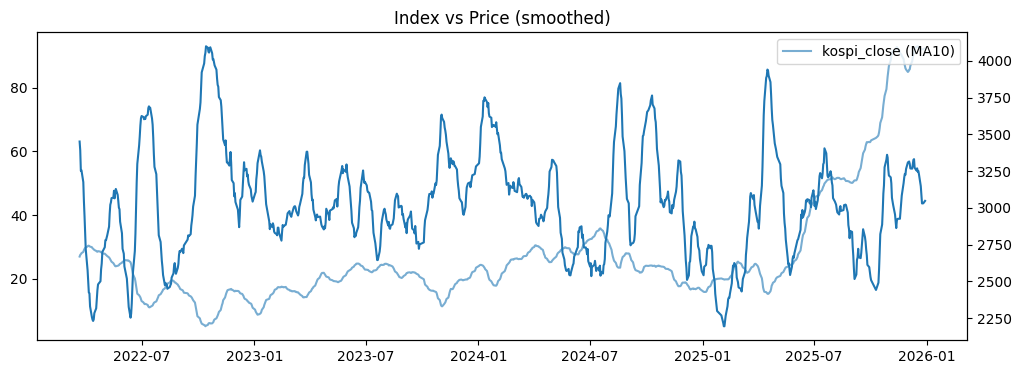

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/3812713234.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["crisis","normal","calm"], showfliers=False)


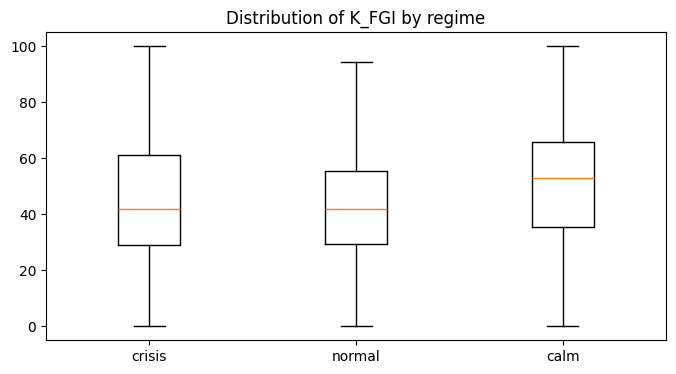

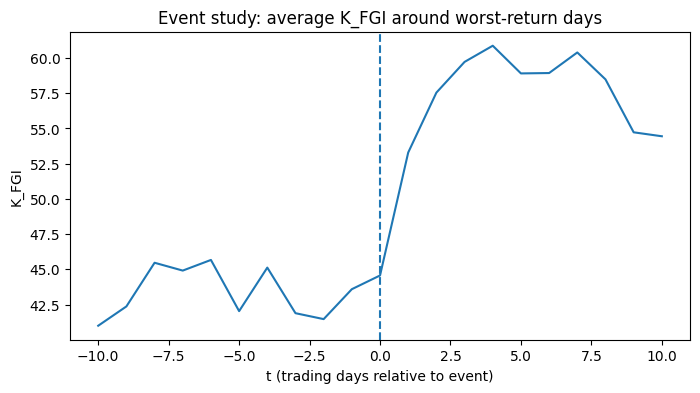

In [32]:
res_orig = validate_sentiment_index(
    df_fgi,
    date_col="date",
    price_col="kospi_close",
    idx_col="K_FGI",
    use_inverted=False,
    crisis_q=0.10,
    calm_q=0.90,
    ma_window=10,
    vol_proxy_col="VKOSPI"   # 없으면 지워도 됨
)


=== Regime summary ===
          n   idx_mean  idx_median    idx_std  ret_mean   ret_std
regime                                                           
calm     94  48.238084   47.126860  20.236972  0.020419  0.007350
crisis   94  55.879615   58.013079  24.326388 -0.021570  0.010514
normal  745  57.205493   58.227446  20.776948  0.000784  0.006805

=== Key deltas (crisis - calm) ===
idx_mean       7.641532
idx_median    10.886218
dtype: float64

=== Correlations ===
corr(idx, ret_1d)   = -0.0605
corr(idx, price)    = 0.1171


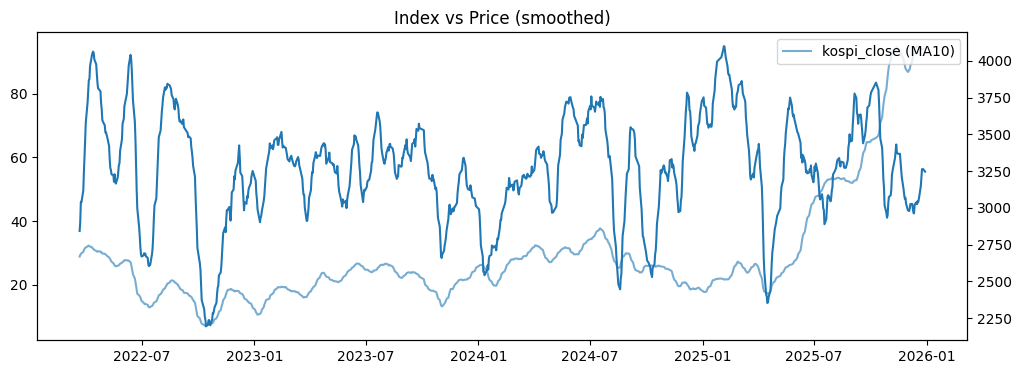

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_22363/3812713234.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["crisis","normal","calm"], showfliers=False)


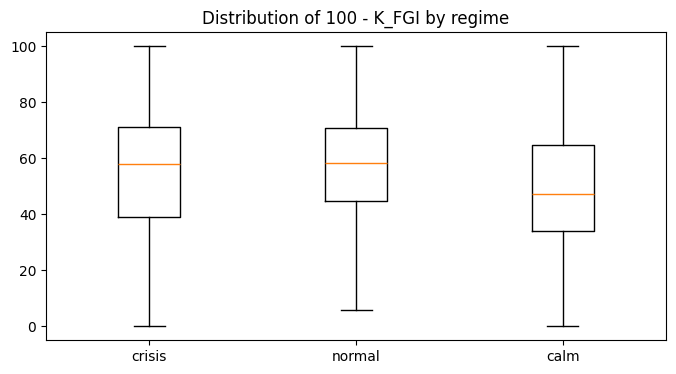

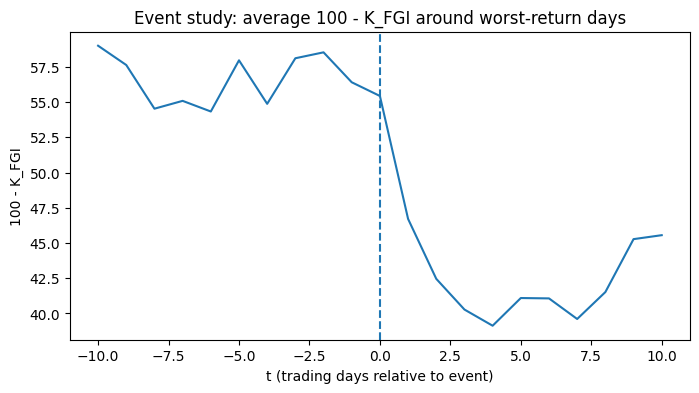

In [33]:
res_flip = validate_sentiment_index(
    df_fgi,
    date_col="date",
    price_col="kospi_close",
    idx_col="K_FGI",
    use_inverted=True,
    crisis_q=0.10,
    calm_q=0.90,
    ma_window=10,
    vol_proxy_col="VKOSPI"   # 없으면 지워도 됨
)